C:\Users\Computação\AppData\Local\Temp\ipykernel_17624\892399191.py:24: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  footprint = morphology.square(3)


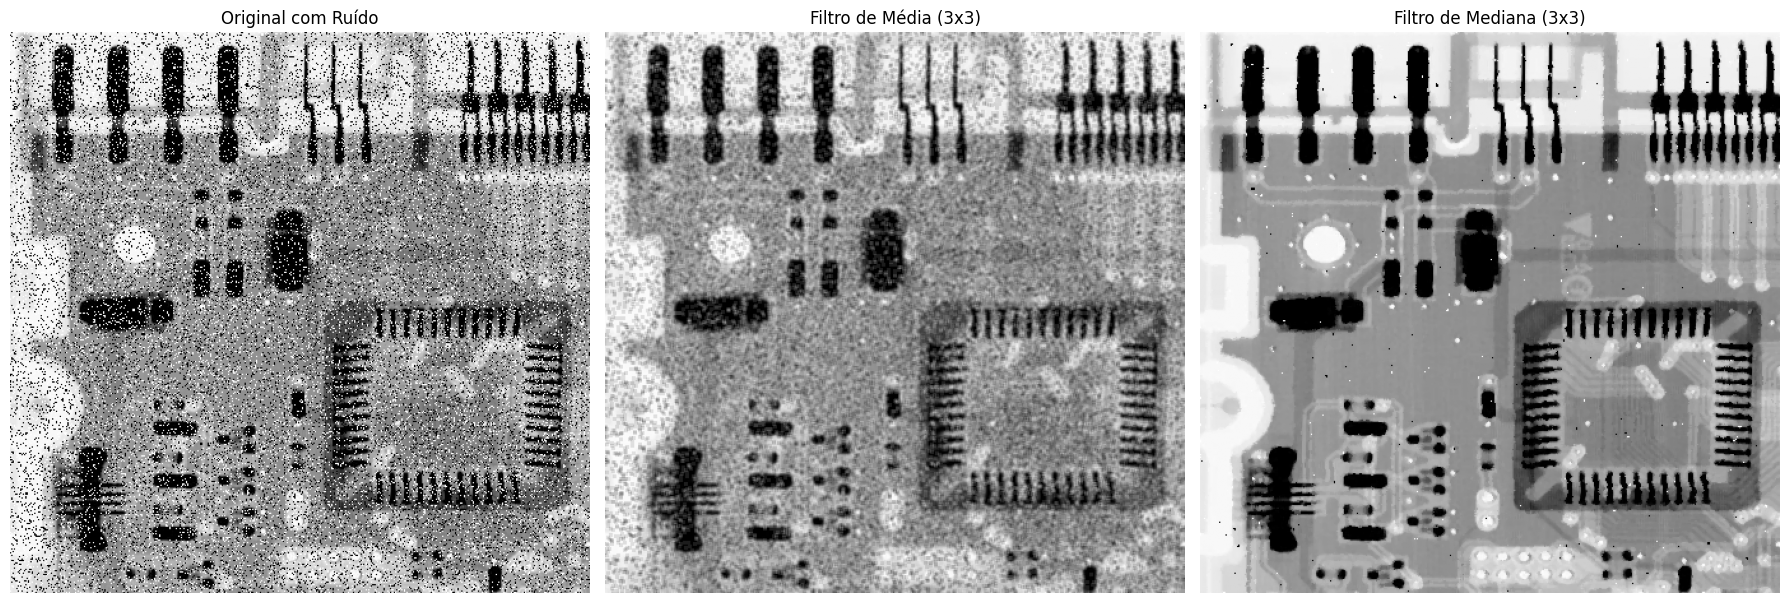

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage import io, color, util, filters, morphology

image_path = './images/FIG033_3.TIF'

try:
    fig_3_35 = io.imread(image_path)
    if fig_3_35 is None:
        raise FileNotFoundError("Erro: Imagem da Figura 3.35 não encontrada.")
except FileNotFoundError as e:
    print(e)
    exit()

img_original_ruido = fig_3_35


if img_original_ruido.ndim > 2:
    img_original_ruido = color.rgb2gray(img_original_ruido)

img_original_ruido = util.img_as_ubyte(img_original_ruido)

footprint = morphology.square(3)

img_filtro_media = filters.rank.mean(img_original_ruido, footprint=footprint)

img_filtro_mediana = filters.rank.median(img_original_ruido, footprint=footprint)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Imagem Original (recortada)
axes[0].imshow(img_original_ruido, cmap='gray')
axes[0].set_title('Original com Ruído')
axes[0].axis('off')

# Resultado do Filtro de Média
axes[1].imshow(img_filtro_media, cmap='gray')
axes[1].set_title('Filtro de Média (3x3)')
axes[1].axis('off')

# Resultado do Filtro de Mediana
axes[2].imshow(img_filtro_mediana, cmap='gray')
axes[2].set_title('Filtro de Mediana (3x3)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

io.imsave('./images/T7-img_filtro_media.png', img_filtro_media)
io.imsave('./images/T7-img_filtro_mediana.png', img_filtro_mediana)